In [2]:
"""
LAI Estimation Pipeline — XGBoost, with Recursive Feature Elimination (RFE)
Source domain: Rema-Kalenga Wildlife Sanctuary
Spatial transfer target: Khadimnagar National Park (KNP)

RFE is applied AFTER hyperparameter tuning, using the tuned XGBoost model as the
evaluator. RFE runs via LOOCV on the 32-plot Rema-Kalenga TRAINING SET ONLY —
the 8-plot held-out test set and the KNP spatial-transfer target are never
touched during feature selection, avoiding data leakage.

From the RFE step onward, rfe_selected_features_xgb (not the full 15-feature
feature_cols) is used for the final model fit, test evaluation, and transfer.
"""

# ============================================================
# SETUP
# ============================================================
get_ipython().system('pip install earthengine-api geemap xgboost -q')

import ee
ee.Authenticate()
ee.Initialize(project='osmgee')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import itertools
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)


In [3]:
# ============================================================
# REMA-KALENGA: BOUNDARY AND SITE LOCATIONS (SOURCE / TRAINING DATA)
# ============================================================
rema_boundary = ee.FeatureCollection('projects/osmgee/assets/RemaKalenga')
rema_sites = ee.FeatureCollection('projects/osmgee/assets/RemaSites')

print('Rema-Kalenga boundary features:', rema_boundary.size().getInfo())
print('Rema-Kalenga sites features:', rema_sites.size().getInfo())

rema_first_feature = rema_sites.first()
print('Available fields:', rema_first_feature.propertyNames().getInfo())

rema_sites_info = rema_sites.select(
    ['ClusterID', 'MEAN_PAR_L', 'XCoord', 'YCoord', 'longitude', 'Llllllatit']
).getInfo()

for f in rema_sites_info['features']:
    print(f['properties'])




Rema-Kalenga boundary features: 1
Rema-Kalenga sites features: 59
Available fields: ['XCoord', 'ClusterID', 'OBJECTID_1', 'FREQUENCY', 'MEAN_PAR_L', 'ClusterID_', 'MEAN_GAP_F', 'system:index', 'YCoord']
{'ClusterID': 5, 'MEAN_PAR_L': 0.33117018625, 'XCoord': 91.62458, 'YCoord': 24.11235}
{'ClusterID': 27, 'MEAN_PAR_L': 3.94414734825, 'XCoord': 91.6306, 'YCoord': 24.165805}
{'ClusterID': 35, 'MEAN_PAR_L': 2.494383216, 'XCoord': 91.6436025, 'YCoord': 24.1705425}
{'ClusterID': 51, 'MEAN_PAR_L': 3.0017175675, 'XCoord': 91.6253075, 'YCoord': 24.2033275}
{'ClusterID': 3, 'MEAN_PAR_L': 2.8599865912, 'XCoord': 91.632832, 'YCoord': 24.109208}
{'ClusterID': 4, 'MEAN_PAR_L': 2.0680925488, 'XCoord': 91.626706, 'YCoord': 24.110476}
{'ClusterID': 7, 'MEAN_PAR_L': 3.1344433786, 'XCoord': 91.629136, 'YCoord': 24.113164}
{'ClusterID': 8, 'MEAN_PAR_L': 2.1191831826, 'XCoord': 91.630112, 'YCoord': 24.114924}
{'ClusterID': 9, 'MEAN_PAR_L': 3.2432822702, 'XCoord': 91.631906, 'YCoord': 24.116332}
{'ClusterI

In [4]:
# ============================================================
# CLEAN FIELD NAMES (XCoord/Llllllatit = longitude, YCoord/longitude = latitude)
# ============================================================
def clean_feature_rema(f):
    lon = ee.Number(f.get('XCoord'))
    lat = ee.Number(f.get('YCoord'))
    par_lai = ee.Number(f.get('MEAN_PAR_L'))
    cluster_id = f.get('ClusterID')

    return ee.Feature(
        ee.Geometry.Point([lon, lat]),
        {
            'cluster_id': cluster_id,
            'par_lai': par_lai,
            'longitude': lon,
            'latitude': lat
        }
    )

rema_sites_clean = rema_sites.map(clean_feature_rema)

print('Cleaned feature count:', rema_sites_clean.size().getInfo())
print('Sample feature:', rema_sites_clean.first().getInfo())




Cleaned feature count: 59
Sample feature: {'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [91.62458, 24.11235]}, 'id': '00000000000000000004', 'properties': {'cluster_id': 5, 'latitude': 24.11235, 'longitude': 91.62458, 'par_lai': 0.33117018625}}


In [5]:
# ============================================================
# SENTINEL-2: LOAD AND FILTER FOR REMA-KALENGA FIELD WINDOW
# ============================================================
rema_field_start = ee.Date('2021-01-01')
rema_field_end = ee.Date('2021-03-31')

rema_s2_collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(rema_boundary) \
    .filterDate(rema_field_start, rema_field_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))

print('Number of available Sentinel-2 scenes (Rema-Kalenga):', rema_s2_collection.size().getInfo())

rema_image_list = rema_s2_collection.toList(rema_s2_collection.size())
n_rema = rema_s2_collection.size().getInfo()
for i in range(n_rema):
    img = ee.Image(rema_image_list.get(i))
    date = img.date().format('YYYY-MM-dd').getInfo()
    cloud = img.get('CLOUDY_PIXEL_PERCENTAGE').getInfo()
    print(f'{date}  —  cloud cover: {cloud:.1f}%')




Number of available Sentinel-2 scenes (Rema-Kalenga): 15
2021-01-01  —  cloud cover: 0.0%
2021-01-06  —  cloud cover: 0.0%
2021-01-16  —  cloud cover: 0.1%
2021-01-26  —  cloud cover: 3.9%
2021-01-31  —  cloud cover: 0.0%
2021-01-31  —  cloud cover: 0.0%
2021-02-05  —  cloud cover: 0.0%
2021-02-10  —  cloud cover: 0.0%
2021-02-15  —  cloud cover: 0.0%
2021-02-25  —  cloud cover: 17.2%
2021-03-02  —  cloud cover: 0.0%
2021-03-12  —  cloud cover: 0.1%
2021-03-17  —  cloud cover: 0.4%
2021-03-22  —  cloud cover: 0.1%
2021-03-27  —  cloud cover: 0.2%


In [6]:
# ============================================================
# CLOUD MASK, COMPOSITE, AND SPECTRAL INDICES
# ============================================================
csPlus = ee.ImageCollection('GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED')
QA_BAND = 'cs_cdf'
CLEAR_THRESHOLD = 0.60

def mask_s2_clouds(image):
    return image.updateMask(image.select(QA_BAND).gte(CLEAR_THRESHOLD)) \
                .divide(10000).copyProperties(image, image.propertyNames())

rema_s2_masked = rema_s2_collection.linkCollection(csPlus, [QA_BAND]).map(mask_s2_clouds)
rema_s2_composite = rema_s2_masked.median().clip(rema_boundary)

def add_indices(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    gndvi = image.normalizedDifference(['B8', 'B3']).rename('GNDVI')

    evi = image.expression(
        '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))', {
            'NIR': image.select('B8'),
            'RED': image.select('B4'),
            'BLUE': image.select('B2')
        }).rename('EVI')

    savi = image.expression(
        '((NIR - RED) / (NIR + RED + 0.5)) * 1.5', {
            'NIR': image.select('B8'),
            'RED': image.select('B4')
        }).rename('SAVI')

    msavi = image.expression(
        '(2 * NIR + 1 - sqrt((2 * NIR + 1)**2 - 8 * (NIR - RED))) / 2', {
            'NIR': image.select('B8'),
            'RED': image.select('B4')
        }).rename('MSAVI')

    return image.addBands([ndvi, gndvi, evi, savi, msavi])

rema_s2_with_indices = add_indices(rema_s2_composite)

raw_bands = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
index_bands = ['NDVI', 'EVI', 'SAVI', 'GNDVI', 'MSAVI']

final_image_rema = rema_s2_with_indices.select(raw_bands + index_bands)
print('Bands in Rema-Kalenga composite:', final_image_rema.bandNames().getInfo())




Bands in Rema-Kalenga composite: ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12', 'NDVI', 'EVI', 'SAVI', 'GNDVI', 'MSAVI']


In [7]:
# ============================================================
# BUILD 15m x 15m SQUARE PLOTS AND EXTRACT MEAN SPECTRAL VALUES
# ============================================================
def make_square_plot(feature):
    point = feature.geometry()
    half_side = 7.5
    square = point.buffer(half_side, 1).bounds()
    return feature.setGeometry(square)

rema_sites_squares = rema_sites_clean.map(make_square_plot)
sample_geom = rema_sites_squares.first().geometry().getInfo()
print('Sample square plot geometry (Rema-Kalenga):', sample_geom)

rema_extracted = final_image_rema.reduceRegions(
    collection=rema_sites_squares,
    reducer=ee.Reducer.mean(),
    scale=10
)

rema_extracted_info = rema_extracted.getInfo()

for f in rema_extracted_info['features'][:5]:
    print(f['properties'])
    print('---')

rema_rows = [f['properties'] for f in rema_extracted_info['features']]
df_rema = pd.DataFrame(rema_rows)

id_cols = ['cluster_id', 'par_lai', 'longitude', 'latitude']
other_cols = [c for c in df_rema.columns if c not in id_cols]
df_rema = df_rema[id_cols + other_cols]
df_rema




Sample square plot geometry (Rema-Kalenga): {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[91.6245064407107, 24.112283907026445], [91.62465051076359, 24.112283907026445], [91.62465051076359, 24.112417491494657], [91.6245064407107, 24.112417491494657], [91.6245064407107, 24.112283907026445]]]}
{'B11': 0.1424313874126094, 'B12': 0.07605951846821639, 'B2': 0.03815986338753643, 'B3': 0.05632864605271182, 'B4': 0.05276878090578532, 'B5': 0.08955574836933387, 'B6': 0.16989056556445653, 'B7': 0.1979732388953197, 'B8': 0.21721595298262442, 'B8A': 0.22457821902341332, 'EVI': 0.3295240016478683, 'GNDVI': 0.5881837211007394, 'MSAVI': 0.2865358184444568, 'NDVI': 0.6093240450955764, 'SAVI': 0.32037186901020626, 'cluster_id': 5, 'latitude': 24.11235, 'longitude': 91.62458, 'par_lai': 0.33117018625}
---
{'B11': 0.13595642711756364, 'B12': 0.07419382416568121, 'B2': 0.03904888607676606, 'B3': 0.055418353732259965, 'B4': 0.04904271107595126, 'B5': 0.08608490824188214, 'B6': 0.1677384221635592

,cluster_id,par_lai,longitude,latitude,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,EVI,GNDVI,MSAVI,NDVI,SAVI
0,5,0.331170,91.624580,24.112350,0.142431,0.076060,0.038160,0.056329,0.052769,0.089556,0.169891,0.197973,0.217216,0.224578,0.329524,0.588184,0.286536,0.609324,0.320372
1,27,3.944147,91.630600,24.165805,0.135956,0.074194,0.039049,0.055418,0.049043,0.086085,0.167738,0.199248,0.211423,0.219806,0.334650,0.584908,0.285506,0.623535,0.320201
2,35,2.494383,91.643603,24.170542,0.132900,0.062900,0.034079,0.053245,0.042256,0.083800,0.187600,0.217200,0.236031,0.241500,0.392635,0.631831,0.343403,0.696248,0.373438
3,51,3.001718,91.625308,24.203328,0.141376,0.068436,0.045108,0.061773,0.057101,0.094538,0.170199,0.194622,0.201960,0.213711,0.300095,0.531006,0.251252,0.558760,0.286011
4,3,2.859987,91.632832,24.109208,0.133116,0.067745,0.031370,0.051638,0.039897,0.077071,0.164909,0.193969,0.220625,0.221189,0.368735,0.620361,0.323280,0.693238,0.356231
5,4,2.068093,91.626706,24.110476,0.148203,0.080440,0.034296,0.055003,0.043630,0.088897,0.180690,0.207163,0.230051,0.235389,0.376897,0.614208,0.329475,0.680068,0.360656
6,7,3.134443,91.629136,24.113164,0.130188,0.063803,0.031162,0.051708,0.044645,0.087437,0.170949,0.204057,0.208000,0.226724,0.328757,0.601572,0.290158,0.646415,0.325443
7,8,2.119183,91.630112,24.114924,0.124400,0.057700,0.028650,0.050205,0.039200,0.079700,0.187600,0.213200,0.227003,0.235100,0.376415,0.637759,0.335942,0.705474,0.367657
8,9,3.243282,91.631906,24.116332,0.129149,0.063149,0.033115,0.052032,0.042974,0.082926,0.175470,0.215170,0.237336,0.238305,0.389424,0.639471,0.343496,0.692662,0.373193
9,10,4.013032,91.635002,24.115710,0.132565,0.062171,0.031575,0.048792,0.037998,0.083369,0.192167,0.227811,0.247637,0.250866,0.422723,0.670577,0.373621,0.733398,0.399795


In [8]:
# ============================================================
# TRAIN / TEST SPLIT (80/20 -> 32/8)
# ============================================================
feature_cols = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12',
                 'NDVI', 'EVI', 'SAVI', 'GNDVI', 'MSAVI']
target_col = 'par_lai'

X_rema = df_rema[feature_cols]
y_rema = df_rema[target_col]

X_train_rema, X_test_rema, y_train_rema, y_test_rema = train_test_split(
    X_rema, y_rema, test_size=0.2, random_state=42
)

print('Train PAR LAI range:', round(y_train_rema.min(), 2), '-', round(y_train_rema.max(), 2))
print('Test PAR LAI range:', round(y_test_rema.min(), 2), '-', round(y_test_rema.max(), 2))
print('Train PAR LAI mean:', round(y_train_rema.mean(), 2))
print('Test PAR LAI mean:', round(y_test_rema.mean(), 2))




Train PAR LAI range: 0.35 - 4.29
Test PAR LAI range: 0.33 - 3.62
Train PAR LAI mean: 2.17
Test PAR LAI mean: 2.17


In [9]:
# ============================================================
# XGBOOST — HYPERPARAMETER SEARCH VIA LOOCV
# ============================================================
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.85, 1.0]
}

xgb_keys = list(xgb_param_grid.keys())
xgb_combinations = list(itertools.product(*xgb_param_grid.values()))
print(f'Total XGBoost hyperparameter combinations to test: {len(xgb_combinations)}')

loo = LeaveOneOut()
xgb_results = []

for combo in xgb_combinations:
    params = dict(zip(xgb_keys, combo))
    model = XGBRegressor(random_state=42, verbosity=0, **params)

    scores = cross_val_score(model, X_train_rema, y_train_rema, cv=loo, scoring='neg_mean_squared_error')
    mean_mse = -scores.mean()
    rmse = np.sqrt(mean_mse)

    xgb_results.append({**params, 'loocv_rmse': rmse})

xgb_results_df = pd.DataFrame(xgb_results).sort_values('loocv_rmse').reset_index(drop=True)
print('Top 5 XGBoost hyperparameter combinations by LOOCV RMSE:')
print(xgb_results_df.head(5))




Total XGBoost hyperparameter combinations to test: 108
Top 5 XGBoost hyperparameter combinations by LOOCV RMSE:
   n_estimators  max_depth  learning_rate  subsample  loocv_rmse
0           100          2           0.01       1.00    0.821128
1           300          2           0.01       1.00    0.822429
2           200          2           0.01       1.00    0.823000
3           200          2           0.01       0.85    0.823437
4           100          2           0.01       0.85    0.825552


In [10]:
# ============================================================
# EXTRACT BEST HYPERPARAMETERS
# ============================================================
best_params_xgb = xgb_results_df.iloc[0][xgb_keys].to_dict()
best_params_xgb['n_estimators'] = int(best_params_xgb['n_estimators'])
best_params_xgb['max_depth'] = int(best_params_xgb['max_depth'])
best_params_xgb['learning_rate'] = float(best_params_xgb['learning_rate'])
best_params_xgb['subsample'] = float(best_params_xgb['subsample'])

print('Best hyperparameters selected via LOOCV (XGBoost, Rema-Kalenga):')
print(best_params_xgb)


def compute_metrics(y_true, y_pred, label):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    rrmse = (rmse / y_true.mean()) * 100
    bias = (y_pred - y_true).mean()
    return {
        'Set': label,
        'N': len(y_true),
        'R2': round(r2, 3),
        'RMSE': round(rmse, 3),
        'MAE': round(mae, 3),
        'rRMSE (%)': round(rrmse, 1),
        'Bias (mean residual)': round(bias, 3)
    }




Best hyperparameters selected via LOOCV (XGBoost, Rema-Kalenga):
{'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.01, 'subsample': 1.0}



STARTING RFE — XGBoost (Rema-Kalenga training set, LOOCV)

Iteration 1: 15 features -> LOOCV RMSE = 0.821 (change from baseline: +0.000)
  Removing: ['B6']

Iteration 2: 14 features -> LOOCV RMSE = 0.819 (change from baseline: -0.002)
  Removing: ['EVI']

Iteration 3: 13 features -> LOOCV RMSE = 0.818 (change from baseline: -0.003)
  Removing: ['SAVI']

Iteration 4: 12 features -> LOOCV RMSE = 0.818 (change from baseline: -0.003)
  Removing: ['MSAVI']

Iteration 5: 11 features -> LOOCV RMSE = 0.815 (change from baseline: -0.006)
  Removing: ['B5']

Iteration 6: 10 features -> LOOCV RMSE = 0.806 (change from baseline: -0.015)
  Removing: ['B8A']

Iteration 7: 9 features -> LOOCV RMSE = 0.803 (change from baseline: -0.018)
  Removing: ['B12']

Iteration 8: 8 features -> LOOCV RMSE = 0.818 (change from baseline: -0.004)
  Removing: ['B7']

Iteration 9: 7 features -> LOOCV RMSE = 0.809 (change from baseline: -0.012)
  Removing: ['B2']

Iteration 10: 6 features -> LOOCV RMSE = 0.805 (chang

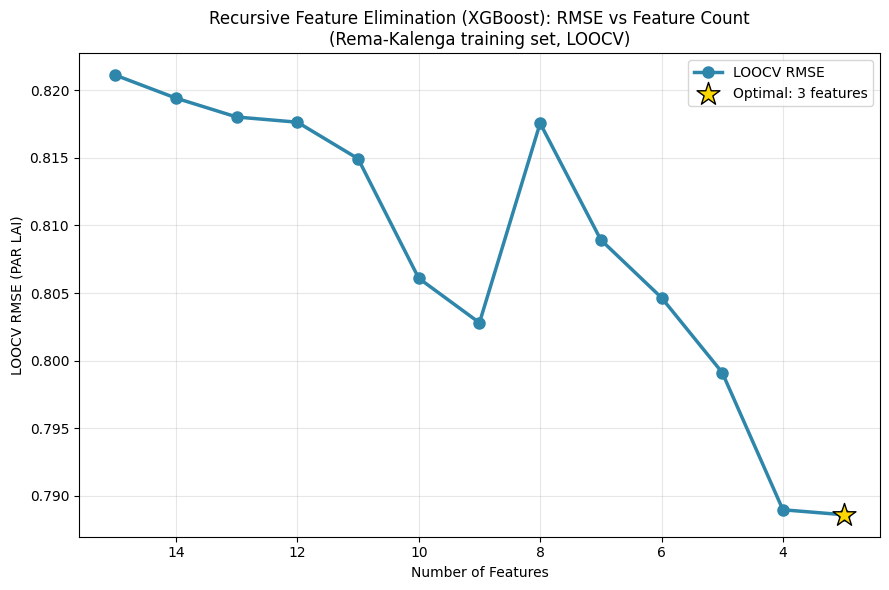

In [11]:
# ============================================================
# RECURSIVE FEATURE ELIMINATION (RFE) — XGBOOST
# Runs AFTER hyperparameter tuning, using the tuned XGBoost hyperparameters as
# the evaluator. Operates ONLY on the 32-plot training set via LOOCV — the
# 8-plot test set and the KNP spatial-transfer target are never touched here.
# ============================================================
min_features = 3                 # safety floor given only 32 training samples
elimination_step = 1              # remove 1 feature per iteration
absolute_drop_threshold = 0.15    # stop if LOOCV RMSE rises by more than this (LAI units)

current_features_xgb = feature_cols.copy()
rfe_results_xgb = []
iteration = 0

print('\n' + '='*60)
print('STARTING RFE — XGBoost (Rema-Kalenga training set, LOOCV)')
print('='*60)

start_time = time.time()

while True:
    iteration += 1
    n_current = len(current_features_xgb)

    xgb_eval = XGBRegressor(random_state=42, verbosity=0, **best_params_xgb)
    scores = cross_val_score(
        xgb_eval,
        X_train_rema[current_features_xgb],
        y_train_rema,
        cv=loo,
        scoring='neg_mean_squared_error'
    )
    rmse = np.sqrt(-scores.mean())

    if len(rfe_results_xgb) == 0:
        baseline_rmse = rmse
        rmse_increase = 0.0
    else:
        baseline_rmse = rfe_results_xgb[0]['rmse']
        rmse_increase = rmse - baseline_rmse

    print(f'\nIteration {iteration}: {n_current} features -> LOOCV RMSE = {rmse:.3f} '
          f'(change from baseline: {rmse_increase:+.3f})')

    rfe_results_xgb.append({
        'iteration': iteration,
        'n_features': n_current,
        'features': current_features_xgb.copy(),
        'rmse': rmse,
        'rmse_increase': rmse_increase
    })

    should_stop = False
    if len(rfe_results_xgb) > 1 and rmse_increase > absolute_drop_threshold:
        should_stop = True
        print(f'  STOPPING: RMSE rose by {rmse_increase:.3f} (threshold: {absolute_drop_threshold})')
    if n_current <= min_features:
        should_stop = True
        print(f'  STOPPING: reached minimum feature count ({min_features})')

    if should_stop:
        break

    xgb_importance = XGBRegressor(random_state=42, verbosity=0, **best_params_xgb)
    xgb_importance.fit(X_train_rema[current_features_xgb], y_train_rema)
    importances = dict(zip(current_features_xgb, xgb_importance.feature_importances_))

    sorted_feats = sorted(importances.items(), key=lambda x: x[1])
    n_to_remove = min(elimination_step, len(current_features_xgb) - min_features)
    features_to_remove = [f for f, _ in sorted_feats[:n_to_remove]]
    print(f'  Removing: {features_to_remove}')

    current_features_xgb = [f for f in current_features_xgb if f not in features_to_remove]

total_time = time.time() - start_time

best_rfe_xgb = min(rfe_results_xgb, key=lambda x: x['rmse'])
rfe_selected_features_xgb = best_rfe_xgb['features']

print('\n' + '='*60)
print('RFE COMPLETE — XGBoost')
print('='*60)
print(f'Total time: {total_time/60:.1f} min')
print(f'Optimal feature count: {best_rfe_xgb["n_features"]}')
print(f'Optimal features: {rfe_selected_features_xgb}')
print(f'Optimal LOOCV RMSE: {best_rfe_xgb["rmse"]:.3f} (baseline was {rfe_results_xgb[0]["rmse"]:.3f})')

# --- Plot: LOOCV RMSE vs number of features ---
rfe_df_xgb = pd.DataFrame(rfe_results_xgb)

plt.figure(figsize=(9, 6))
plt.plot(rfe_df_xgb['n_features'], rfe_df_xgb['rmse'], marker='o', markersize=8,
         linewidth=2.5, color='#2E86AB', label='LOOCV RMSE')

best_idx_xgb = rfe_df_xgb['rmse'].idxmin()
plt.scatter(rfe_df_xgb.loc[best_idx_xgb, 'n_features'], rfe_df_xgb.loc[best_idx_xgb, 'rmse'],
            color='gold', s=300, marker='*', zorder=5, edgecolor='black',
            label=f'Optimal: {rfe_df_xgb.loc[best_idx_xgb, "n_features"]} features')

plt.xlabel('Number of Features')
plt.ylabel('LOOCV RMSE (PAR LAI)')
plt.title('Recursive Feature Elimination (XGBoost): RMSE vs Feature Count\n(Rema-Kalenga training set, LOOCV)')
plt.gca().invert_xaxis()
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()




=== Rema-Kalenga XGBoost model performance summary (RFE-selected features) ===
                                                  Set  N    R2  RMSE   MAE  rRMSE (%)  Bias (mean residual)
Rema-Kalenga Train (in-sample, XGBoost, RFE features) 47 0.434 0.662 0.523       30.6                -0.006
  Rema-Kalenga Test (held-out, XGBoost, RFE features) 12 0.185 0.809 0.647       37.3                -0.030

=== Feature importance (Rema-Kalenga XGBoost model, RFE-selected features) ===
Feature  Importance
    B11    0.445193
  GNDVI    0.321769
   NDVI    0.233038

=== Per-plot residuals (Rema-Kalenga test set, XGBoost, RFE features) ===
 cluster_id  observed_par_lai  predicted_par_lai  residual
          5          0.331170              2.147     1.815
          4          2.068093              2.037    -0.031
         42          1.949388              2.241     0.292
         14          1.625104              2.194     0.569
         56          3.173609              2.699    -0.474
        

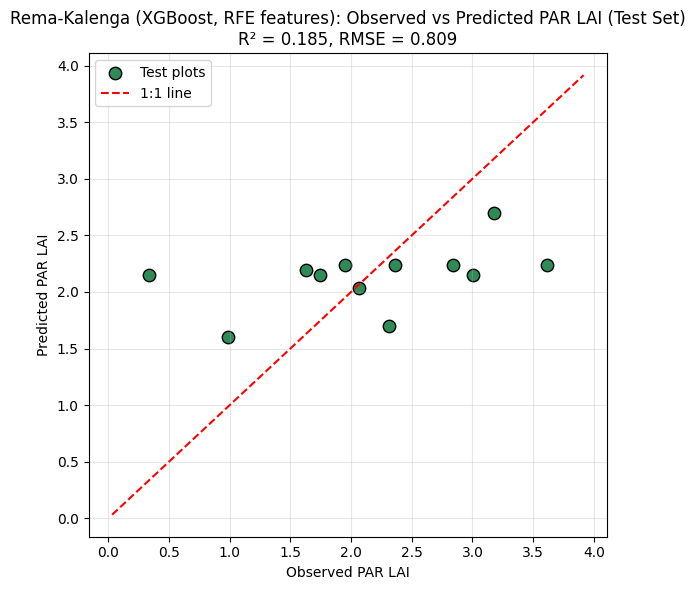

In [12]:
# ============================================================
# REFIT FINAL MODEL ON RFE-SELECTED FEATURES — THIS IS THE MODEL USED FOR TRANSFER
# ============================================================
final_xgb_rema = XGBRegressor(random_state=42, verbosity=0, **best_params_xgb)
final_xgb_rema.fit(X_train_rema[rfe_selected_features_xgb], y_train_rema)

y_pred_train_rema_xgb = final_xgb_rema.predict(X_train_rema[rfe_selected_features_xgb])
y_pred_test_rema_xgb = final_xgb_rema.predict(X_test_rema[rfe_selected_features_xgb])

metrics_train_rema_xgb = compute_metrics(y_train_rema, y_pred_train_rema_xgb, 'Rema-Kalenga Train (in-sample, XGBoost, RFE features)')
metrics_test_rema_xgb = compute_metrics(y_test_rema, y_pred_test_rema_xgb, 'Rema-Kalenga Test (held-out, XGBoost, RFE features)')

metrics_df_rema_xgb = pd.DataFrame([metrics_train_rema_xgb, metrics_test_rema_xgb])
print('=== Rema-Kalenga XGBoost model performance summary (RFE-selected features) ===')
print(metrics_df_rema_xgb.to_string(index=False))
print()

importance_df_rema_xgb = pd.DataFrame({
    'Feature': rfe_selected_features_xgb,
    'Importance': final_xgb_rema.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('=== Feature importance (Rema-Kalenga XGBoost model, RFE-selected features) ===')
print(importance_df_rema_xgb.to_string(index=False))
print()

residuals_df_rema_xgb = pd.DataFrame({
    'cluster_id': df_rema.loc[X_test_rema.index, 'cluster_id'].values,
    'observed_par_lai': y_test_rema.values,
    'predicted_par_lai': y_pred_test_rema_xgb.round(3),
    'residual': (y_pred_test_rema_xgb - y_test_rema.values).round(3)
})
print('=== Per-plot residuals (Rema-Kalenga test set, XGBoost, RFE features) ===')
print(residuals_df_rema_xgb.to_string(index=False))
print()

plt.figure(figsize=(6, 6))
plt.scatter(y_test_rema, y_pred_test_rema_xgb, color='seagreen', edgecolor='black', s=80, label='Test plots')
lims = [min(y_test_rema.min(), y_pred_test_rema_xgb.min()) - 0.3,
        max(y_test_rema.max(), y_pred_test_rema_xgb.max()) + 0.3]
plt.plot(lims, lims, 'r--', label='1:1 line')
plt.xlabel('Observed PAR LAI')
plt.ylabel('Predicted PAR LAI')
plt.title(f'Rema-Kalenga (XGBoost, RFE features): Observed vs Predicted PAR LAI (Test Set)\n'
          f'R² = {metrics_test_rema_xgb["R2"]}, RMSE = {metrics_test_rema_xgb["RMSE"]}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()




In [13]:
# ============================================================
# NAIVE SPATIAL TRANSFER: KNP (TRANSFER TARGET)
# ============================================================
knp_boundary = ee.FeatureCollection('projects/osmgee/assets/KNP')
knp_sites = ee.FeatureCollection('projects/osmgee/assets/SitesLocation')

print('KNP boundary features:', knp_boundary.size().getInfo())
print('KNP sites features:', knp_sites.size().getInfo())

def clean_feature_knp(f):
    lon = ee.Number(f.get('XCoord'))
    lat = ee.Number(f.get('YCoord'))
    par_lai = ee.Number(f.get('MEAN_PAR_L'))
    cluster_id = f.get('ClusterID')

    return ee.Feature(
        ee.Geometry.Point([lon, lat]),
        {
            'cluster_id': cluster_id,
            'par_lai': par_lai,
            'longitude': lon,
            'latitude': lat
        }
    )

knp_sites_clean = knp_sites.map(clean_feature_knp)

print('Cleaned feature count:', knp_sites_clean.size().getInfo())
print('Sample feature:', knp_sites_clean.first().getInfo())

knp_sites_squares = knp_sites_clean.map(make_square_plot)
print('Sample square geometry (KNP):', knp_sites_squares.first().geometry().getInfo())

# KNP field campaign window (March 2022)
knp_apply_start = ee.Date('2022-01-01')
knp_apply_end = ee.Date('2022-03-31')

knp_s2_collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(knp_boundary) \
    .filterDate(knp_apply_start, knp_apply_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))

print('Number of available Sentinel-2 scenes (Jan-Mar 2022, KNP):', knp_s2_collection.size().getInfo())

knp_image_list = knp_s2_collection.toList(knp_s2_collection.size())
n_knp = knp_s2_collection.size().getInfo()
for i in range(n_knp):
    img = ee.Image(knp_image_list.get(i))
    date = img.date().format('YYYY-MM-dd').getInfo()
    cloud = img.get('CLOUDY_PIXEL_PERCENTAGE').getInfo()
    print(f'{date}  —  cloud cover: {cloud:.1f}%')

knp_s2_masked = knp_s2_collection.linkCollection(csPlus, [QA_BAND]).map(mask_s2_clouds)
knp_s2_composite = knp_s2_masked.median().clip(knp_boundary)
knp_s2_with_indices = add_indices(knp_s2_composite)

final_image_knp = knp_s2_with_indices.select(raw_bands + index_bands)
print('Bands in KNP composite:', final_image_knp.bandNames().getInfo())

knp_extracted = final_image_knp.reduceRegions(
    collection=knp_sites_squares,
    reducer=ee.Reducer.mean(),
    scale=10
)

knp_extracted_info = knp_extracted.getInfo()
knp_rows = [f['properties'] for f in knp_extracted_info['features']]
df_knp = pd.DataFrame(knp_rows)

other_cols = [c for c in df_knp.columns if c not in id_cols]
df_knp = df_knp[id_cols + other_cols]

print(f'Extracted {len(df_knp)} plots')
df_knp




KNP boundary features: 1
KNP sites features: 40
Cleaned feature count: 40
Sample feature: {'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [91.94278, 24.95203]}, 'id': '0000000000000000000c', 'properties': {'cluster_id': '20', 'latitude': 24.95203, 'longitude': 91.94278, 'par_lai': 1.6706171335}}
Sample square geometry (KNP): {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[91.94270594703491, 24.951963907026418], [91.94285098397934, 24.951963907026418], [91.94285098397934, 24.952097491494666], [91.94270594703491, 24.952097491494666], [91.94270594703491, 24.951963907026418]]]}
Number of available Sentinel-2 scenes (Jan-Mar 2022, KNP): 11
2022-01-01  —  cloud cover: 10.0%
2022-01-06  —  cloud cover: 19.3%
2022-01-26  —  cloud cover: 19.8%
2022-01-31  —  cloud cover: 1.5%
2022-02-15  —  cloud cover: 0.0%
2022-02-20  —  cloud cover: 3.5%
2022-03-02  —  cloud cover: 0.0%
2022-03-07  —  cloud cover: 0.0%
2022-03-12  —  cloud cover: 23.7%
2022-03-17  —  cloud cover: 0.

,cluster_id,par_lai,longitude,latitude,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,EVI,GNDVI,MSAVI,NDVI,SAVI
0,20,1.670617,91.942780,24.952030,0.148272,0.071148,0.030400,0.046465,0.033724,0.083295,0.210989,0.256052,0.269581,0.288476,0.473796,0.706005,0.422154,0.777459,0.440098
1,2,3.038662,91.937182,24.952476,0.121299,0.054796,0.028936,0.048881,0.042311,0.073137,0.164237,0.199635,0.239743,0.225284,0.383648,0.657121,0.346851,0.698811,0.375263
2,27,2.154577,91.943748,24.945720,0.196215,0.114333,0.034056,0.054561,0.045360,0.107156,0.201953,0.242526,0.273257,0.267208,0.441903,0.667430,0.396632,0.716456,0.417396
3,40,0.285474,91.961718,24.971386,0.196767,0.120137,0.034067,0.051791,0.043418,0.099073,0.194840,0.228898,0.228201,0.254464,0.374257,0.629236,0.327087,0.679469,0.358600
4,11,3.923973,91.938690,24.952073,0.120839,0.056409,0.026086,0.043782,0.031075,0.073244,0.176348,0.213370,0.225074,0.234936,0.398095,0.672083,0.353558,0.755377,0.383709
5,13,3.148044,91.938552,24.954740,0.129963,0.066591,0.034634,0.051700,0.044072,0.079737,0.187206,0.230333,0.234959,0.256375,0.384945,0.637622,0.337546,0.683013,0.367012
6,25,4.923975,91.941830,24.948150,0.116373,0.056025,0.029673,0.041950,0.031873,0.067451,0.156370,0.195738,0.199374,0.201425,0.357448,0.652040,0.306207,0.722405,0.342229
7,32,1.538075,91.958823,24.968853,0.121981,0.059360,0.030057,0.042175,0.032960,0.065891,0.150383,0.184477,0.197692,0.206078,0.351879,0.648200,0.301041,0.713990,0.338077
8,33,3.215866,91.959881,24.966343,0.116688,0.054801,0.022995,0.034053,0.025020,0.061984,0.170161,0.207791,0.211276,0.234723,0.391125,0.721592,0.345815,0.787384,0.378820
9,36,3.479967,91.960536,24.968643,0.127217,0.063176,0.027015,0.041600,0.029176,0.068809,0.166674,0.204009,0.210436,0.224908,0.381259,0.666555,0.332292,0.752735,0.364988


=== Spatial Transfer Performance (Rema-Kalenga XGBoost -> KNP, RFE features) ===
                                                                          Set  N    R2  RMSE   MAE  rRMSE (%)  Bias (mean residual)
Spatial Transfer: Rema-Kalenga XGBoost model (RFE features) -> KNP (40 plots) 40 0.373 0.957 0.769       39.2                 0.111

=== Per-plot residuals (KNP, spatial transfer, XGBoost, RFE features) ===
cluster_id  observed_par_lai  predicted_par_lai  residual
        20             1.671              2.494     0.824
         2             3.039              2.643    -0.396
        27             2.155              2.250     0.096
        40             0.285              1.941     1.655
        11             3.924              2.994    -0.930
        13             3.148              2.241    -0.907
        25             4.924              2.643    -2.281
        32             1.538              2.643     1.104
        33             3.216              2.994    -0.222


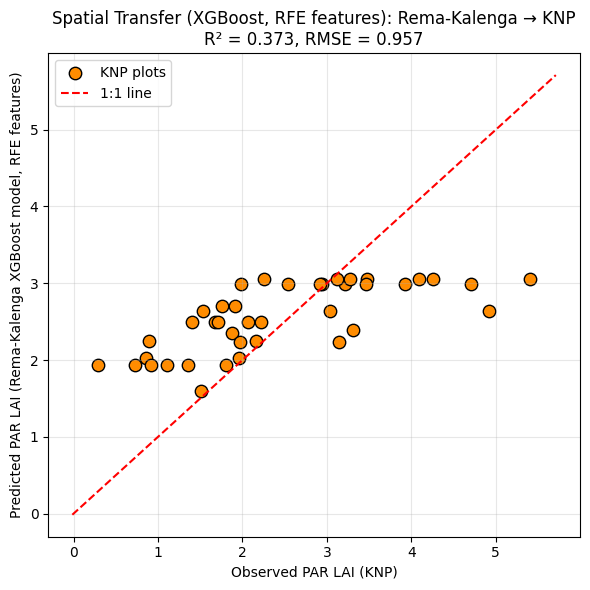

In [14]:
# ============================================================
# APPLY FROZEN XGBOOST MODEL TO KNP (NO RETRAINING) — RFE-SELECTED FEATURES ONLY
# ============================================================
X_knp = df_knp[rfe_selected_features_xgb]
y_knp_true = df_knp['par_lai']

y_knp_pred_xgb = final_xgb_rema.predict(X_knp)

metrics_transfer_knp_xgb = compute_metrics(
    y_knp_true, y_knp_pred_xgb, 'Spatial Transfer: Rema-Kalenga XGBoost model (RFE features) -> KNP (40 plots)'
)
transfer_metrics_df_knp_xgb = pd.DataFrame([metrics_transfer_knp_xgb])

print('=== Spatial Transfer Performance (Rema-Kalenga XGBoost -> KNP, RFE features) ===')
print(transfer_metrics_df_knp_xgb.to_string(index=False))
print()

transfer_residuals_df_knp_xgb = pd.DataFrame({
    'cluster_id': df_knp['cluster_id'],
    'observed_par_lai': y_knp_true.round(3),
    'predicted_par_lai': y_knp_pred_xgb.round(3),
    'residual': (y_knp_pred_xgb - y_knp_true).round(3)
})
print('=== Per-plot residuals (KNP, spatial transfer, XGBoost, RFE features) ===')
print(transfer_residuals_df_knp_xgb.to_string(index=False))
print()

plt.figure(figsize=(6, 6))
plt.scatter(y_knp_true, y_knp_pred_xgb, color='darkorange', edgecolor='black', s=80, label='KNP plots')
lims = [min(y_knp_true.min(), y_knp_pred_xgb.min()) - 0.3,
        max(y_knp_true.max(), y_knp_pred_xgb.max()) + 0.3]
plt.plot(lims, lims, 'r--', label='1:1 line')
plt.xlabel('Observed PAR LAI (KNP)')
plt.ylabel('Predicted PAR LAI (Rema-Kalenga XGBoost model, RFE features)')
plt.title(f'Spatial Transfer (XGBoost, RFE features): Rema-Kalenga → KNP\n'
          f'R² = {metrics_transfer_knp_xgb["R2"]}, RMSE = {metrics_transfer_knp_xgb["RMSE"]}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()




In [15]:
# ============================================================
# EXPORT COMPOSITES TO GOOGLE DRIVE (for later full-map prediction)
# ============================================================
export_task_knp_xgb = ee.batch.Export.image.toDrive(
    image=final_image_knp,
    description='KNP_LAI_features_export_xgb',
    folder='GEE_exports',
    fileNamePrefix='KNP_features_2022_JanMar',
    region=knp_boundary.geometry(),
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)
export_task_knp_xgb.start()
print('KNP export task started. Task ID:', export_task_knp_xgb.id)

export_task_rema_xgb = ee.batch.Export.image.toDrive(
    image=final_image_rema,
    description='RemaKalenga_LAI_features_export_xgb',
    folder='GEE_exports',
    fileNamePrefix='RemaKalenga_features',
    region=rema_boundary.geometry(),
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e13
)
export_task_rema_xgb.start()
print('Rema-Kalenga export task started. Task ID:', export_task_rema_xgb.id)

print('KNP task status:', export_task_knp_xgb.status()['state'])
print('Rema-Kalenga task status:', export_task_rema_xgb.status()['state'])

KNP export task started. Task ID: 5YAEWPXAPWTSC6H6A2LXBLDZ
Rema-Kalenga export task started. Task ID: 7CQZDNNVUH4ZYBDX6JBCSQPV
KNP task status: READY
Rema-Kalenga task status: READY
